In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

In [100]:
df = pd.read_csv("../data/songs.csv")

In [101]:
df.head()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [102]:
df.shape

(114000, 22)

In [103]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name',
       'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability',
       'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')

In [104]:
df.isnull().sum()

Unnamed: 0.1        0
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [105]:
df = df.dropna()

In [106]:
df.isnull().sum()

Unnamed: 0.1        0
Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [107]:
df = df.drop_duplicates()

In [108]:
df.shape

(113999, 22)

In [109]:
df["track_name"].value_counts().head(10)

track_name
Run Rudolph Run                   151
Halloween                          88
Frosty The Snowman                 81
Little Saint Nick - 1991 Remix     76
Last Last                          75
Christmas Time                     72
CÓMO SE SIENTE - Remix             64
Sleigh Ride                        61
RUMBATÓN                           60
X ÚLTIMA VEZ                       58
Name: count, dtype: int64

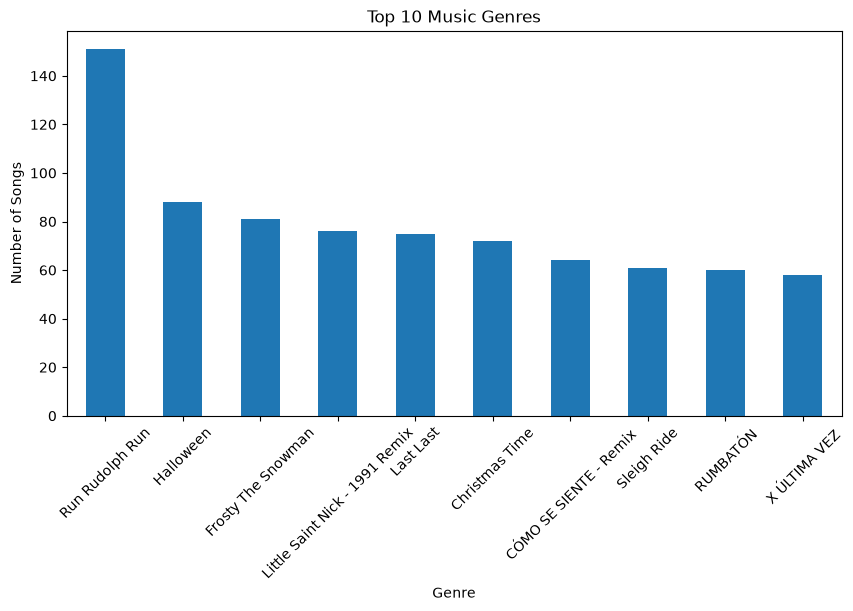

In [110]:
plt.figure(figsize=(10,5))
df["track_name"].value_counts().head(10).plot(kind="bar")
plt.xlabel("Genre")
plt.ylabel("Number of Songs")
plt.title("Top 10 Music Genres")
plt.xticks(rotation=45)
plt.show()

In [111]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name',
       'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability',
       'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')

In [112]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

In [113]:
df[features].describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,0.566801,0.641383,-8.258950,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695
std,0.173543,0.251530,5.029357,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290
min,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.456000,0.472000,-10.013000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500
50%,0.580000,0.685000,-7.004000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000
75%,0.695000,0.854000,-5.003000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000
max,0.985000,1.000000,4.532000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000


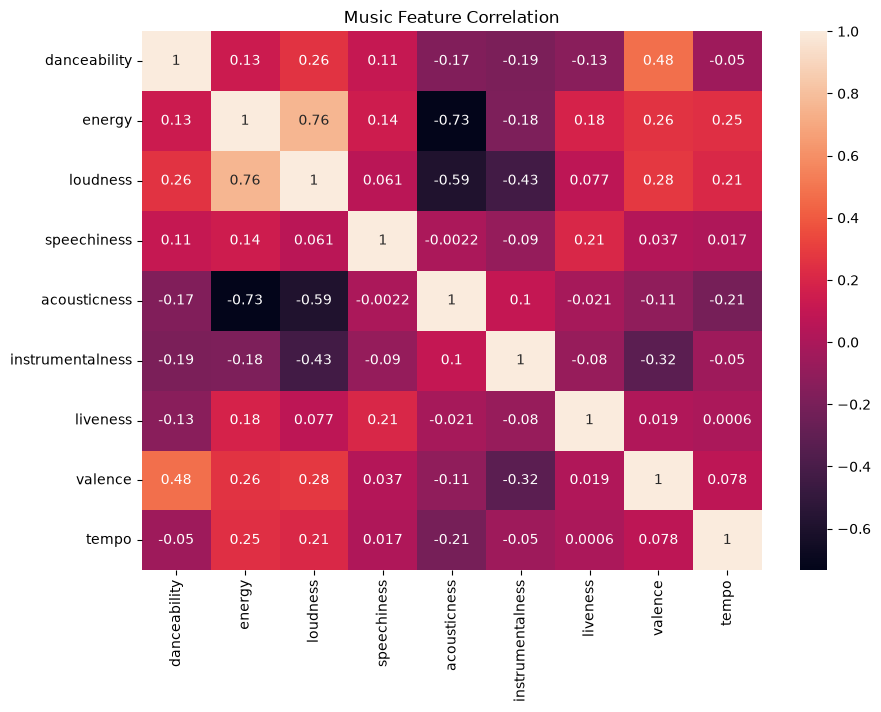

In [114]:
plt.figure(figsize=(10,7))
sns.heatmap(df[features].corr(), annot=True)
plt.title("Music Feature Correlation")
plt.show()

In [115]:
X = df[features]

In [116]:
X.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949


In [117]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [118]:
df = df.reset_index(drop=True)

knn = NearestNeighbors(
    n_neighbors=11,
    metric="cosine",
    algorithm="brute"
)

knn.fit(X_scaled) 

def recommend_songs(song_name, num_recommendations=10):
    if song_name not in song_indices:
        return pd.DataFrame()

    idx = song_indices[song_name]

    distances, indices = knn.kneighbors(
        X_scaled[idx:idx+1],
        n_neighbors=num_recommendations + 1
    )

    recommended_indices = indices[0][1:]
    recommended_distances = distances[0][1:]

    result = df.iloc[recommended_indices][
        ["track_name", "artists", "track_genre"]
    ].copy()

    result["similarity"] = 1 - recommended_distances

    return result.reset_index(drop=True) 

In [119]:
song_indices = pd.Series(
    df.index,
    index=df["track_name"]
).to_dict()

In [120]:
df["track_name"].head(20)

0                               Comedy
1                     Ghost - Acoustic
2                       To Begin Again
3           Can't Help Falling In Love
4                              Hold On
5                 Days I Will Remember
6                        Say Something
7                            I'm Yours
8                                Lucky
9                               Hunger
10                Give Me Your Forever
11                     I Won't Give Up
12                                Solo
13                            Bad Liar
14                     Hold On - Remix
15    Falling in Love at a Coffee Shop
16               ily (i love you baby)
17                         At My Worst
18                               Lucky
19                          Photograph
Name: track_name, dtype: str

In [121]:
recommend_songs("Blinding Lights")

,track_name,artists,track_genre,similarity
0,Blinding Lights,All Time Low,punk-rock,1.0
1,Blinding Lights,All Time Low,punk,1.0
2,Blinding Lights,All Time Low,punk-rock,1.0
3,Blinding Lights,All Time Low,punk-rock,1.0
4,Blinding Lights,All Time Low,rock,1.0
5,Blinding Lights,All Time Low,rock,1.0
6,Blinding Lights,All Time Low,rock,1.0
7,Blinding Lights,All Time Low,rock,1.0
8,Blinding Lights,All Time Low,punk,1.0
9,Blinding Lights,All Time Low,rock,1.0


In [122]:
df["track_name"].iloc[0]

'Comedy'

In [123]:
recommend_songs(df["track_name"].iloc[0])

,track_name,artists,track_genre,similarity
0,Comedy,Gen Hoshino,songwriter,1.000000
1,Comedy,Gen Hoshino,acoustic,1.000000
2,Comedy,Gen Hoshino,j-pop,1.000000
3,Skylight,Gramatik,trip-hop,0.953221
4,That Certain Female,Charlie Feathers,rockabilly,0.930325
5,Look For The Good (Single Version),Jason Mraz,acoustic,0.929432
6,Monde de fous,Danakil,french,0.929147
7,Monde de fous,Danakil,dub,0.929147
8,Blink 182,Trille,german,0.926133
9,Blink 182,Trille,indie,0.926133


In [124]:
recommend_songs(df["track_name"].iloc[10])

,track_name,artists,track_genre,similarity
0,Give Me Your Forever,Zack Tabudlo,acoustic,1.000000
1,幸福摩天輪,Eason Chan,cantopop,0.978300
2,"Moonlight, Mistletoe & You",Keb' Mo';Gerald Albright,acoustic,0.974717
3,"Moonlight, Mistletoe & You",Keb' Mo';Gerald Albright,blues,0.974717
4,Used To,Sandro Cavazza;Lou Elliotte,swedish,0.962665
5,You're My Waterloo,The Libertines,garage,0.961264
6,Time for Sleep,The Wiggles,children,0.959946
7,More Than Words,Extreme,metal,0.959938
8,More Than Words,Extreme,metal,0.959938
9,More Than Words,Extreme,funk,0.959938


In [125]:
recommend_songs(df["track_name"].iloc[50])

,track_name,artists,track_genre,similarity
0,Trampoline - Acoustic,Highland Peak,acoustic,1.000000
1,Dear Theodosia,Leslie Odom Jr.;Lin-Manuel Miranda,show-tunes,0.997961
2,為什麼,盧業瑂,cantopop,0.996993
3,Rise,Boyce Avenue,acoustic,0.993340
4,The Bomb,Florence + The Machine,alternative,0.991878
5,River,Ben Platt,show-tunes,0.990979
6,Settled Down,Watchhouse,bluegrass,0.989801
7,Please Don't Go Home Yet,Stephen Sanchez,singer-songwriter,0.988490
8,Please Don't Go Home Yet,Stephen Sanchez,songwriter,0.988490
9,遺憾,Abin Fang,mandopop,0.988436


In [126]:
recommend_songs(df["track_name"].iloc[100])

,track_name,artists,track_genre,similarity
0,Rain,Motohiro Hata,j-rock,1.000000
1,Rain,Motohiro Hata,j-pop,1.000000
2,Rain,Motohiro Hata,songwriter,1.000000
3,Rain,Motohiro Hata,singer-songwriter,1.000000
4,Nazm Nazm,Arko,pop-film,0.984648
5,Nazm Nazm,Arko,pop,0.984648
6,The Best Side Of Life,Sarah Connor,german,0.979369
7,The Best Side Of Life,Sarah Connor,german,0.979369
8,The Best Side Of Life,Sarah Connor,german,0.979369
9,The Best Side Of Life,Sarah Connor,german,0.979369


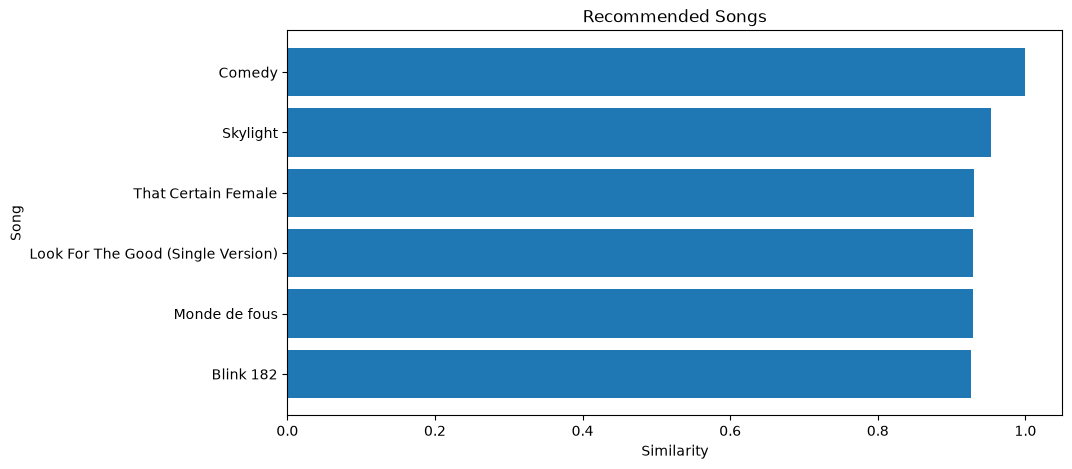

In [127]:
recommendations = recommend_songs(df["track_name"].iloc[0])

plt.figure(figsize=(10,5))
plt.barh(recommendations["track_name"], recommendations["similarity"])
plt.xlabel("Similarity")
plt.ylabel("Song")
plt.title("Recommended Songs")
plt.gca().invert_yaxis()
plt.show()

In [128]:
import pickle

In [130]:
with open("../models/knn.pkl", "wb") as file:
    pickle.dump(knn, file)

In [131]:
with open("../models/X_scaled.pkl", "wb") as file:
    pickle.dump(X_scaled, file)

In [132]:
df.to_pickle("../models/songs.pkl")

In [133]:
song_indices

{'Comedy': 102150,
 'Ghost - Acoustic': 15190,
 'To Begin Again': 2,
 "Can't Help Falling In Love": 92900,
 'Hold On': 111617,
 'Days I Will Remember': 56777,
 'Say Something': 79468,
 "I'm Yours": 91903,
 'Lucky': 106084,
 'Hunger': 79109,
 'Give Me Your Forever': 462,
 "I Won't Give Up": 118,
 'Solo': 103657,
 'Bad Liar': 91017,
 'Hold On - Remix': 14,
 'Falling in Love at a Coffee Shop': 215,
 'ily (i love you baby)': 53893,
 'At My Worst': 103223,
 'Photograph': 81763,
 'Demons': 94642,
 '93 Million Miles': 91669,
 'Unlonely': 91662,
 'Bella Luna': 91661,
 'Winter Wonderland': 92112,
 'If It Kills Me': 91670,
 'All I Want For Christmas Is A Real Good Tan': 32,
 'Party of One': 34218,
 'Lonely This Christmas': 102598,
 'Throwing Good After Bad': 34221,
 'This Time Tomorrow': 34235,
 'The Haves': 40,
 "When You're Wrong": 34222,
 'You and Me on the Rock': 34199,
 'Speak Your Mind (From the Netflix Series "We The People")': 34238,
 'Trampoline - Acoustic': 15387,
 '透明だった世界': 102699,
 

In [134]:
with open("../models/song_indices.pkl", "wb") as file:
    pickle.dump(song_indices, file)